# Exploratory Data Analysis (EDA)

In [ ]:
import os
import random
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from PIL import Image

#from tqdm import tqdm
import torchvision.transforms as T

DATASET_ROOT = "./ASL_Dataset"

TRAIN_PATH = os.path.join(DATASET_ROOT, "train")
TEST_PATH = os.path.join(DATASET_ROOT, "test")

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_pin_memory = True if device.type == "cuda" else False
use_non_blocking = True if device.type == "cuda" else False

In [2]:
class_names = sorted([
    d for d in os.listdir(TRAIN_PATH) 
    if os.path.isdir(os.path.join(TRAIN_PATH, d))
])

print(f"Classes detected: {len(class_names)}")
print(class_names)

Classes detected: 28
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'Nothing', 'O', 'P', 'Q', 'R', 'S', 'Space', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [3]:
def count_images(path):
    counts = {}
    for cls in class_names:
        folder = os.path.join(path, cls)
        counts[cls] = len(os.listdir(folder))
    return pd.DataFrame.from_dict(counts, orient='index', columns=['count'])

train_counts = count_images(TRAIN_PATH)
test_counts = count_images(TEST_PATH)

test_counts.head()

,count
A,4
B,4
C,4
D,4
E,4


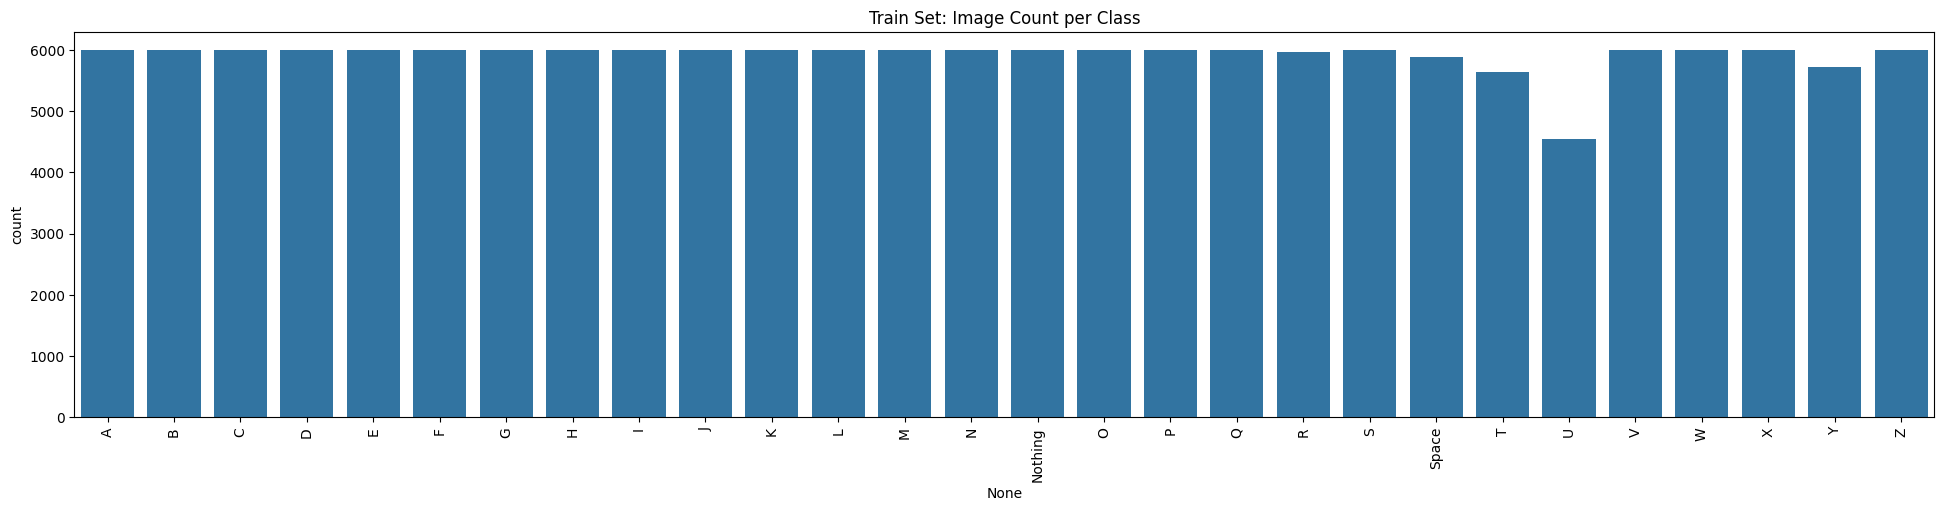

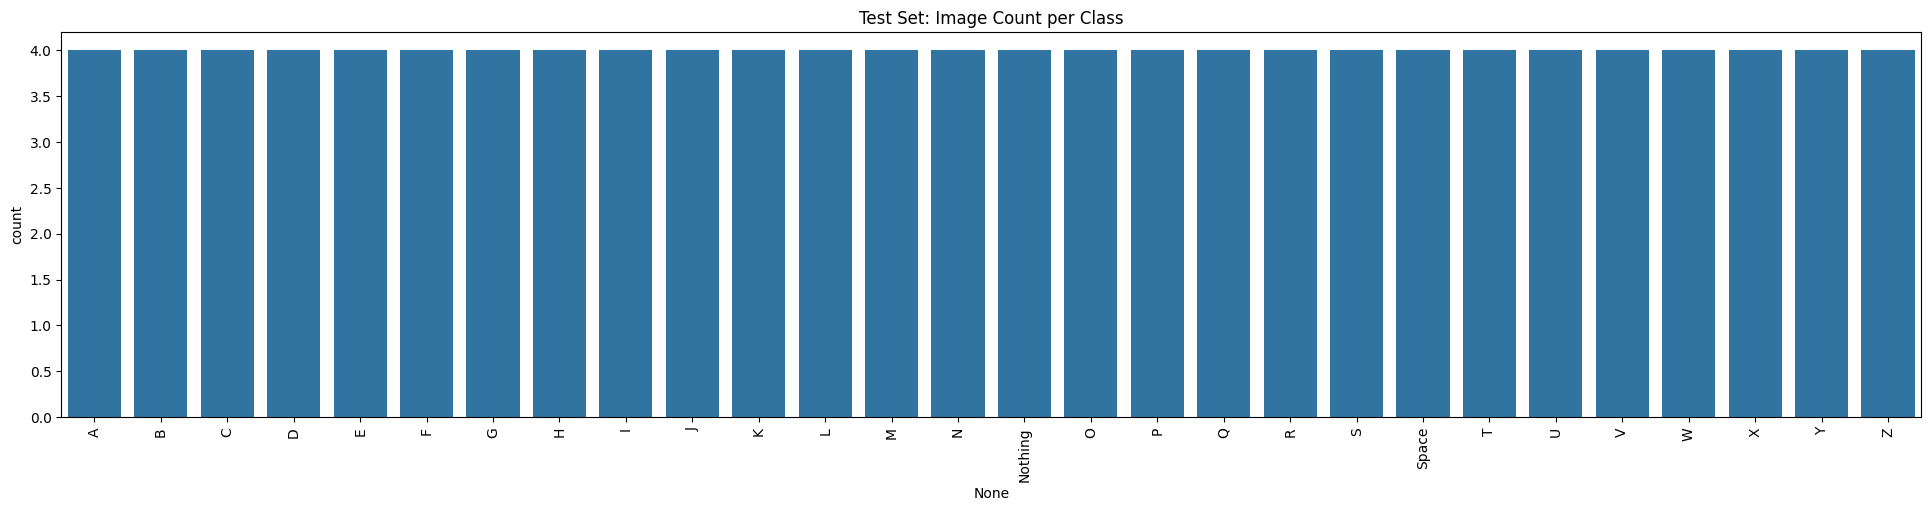

In [4]:
plt.figure(figsize=(24,5))
sns.barplot(x=train_counts.index, y=train_counts['count'])
plt.title("Train Set: Image Count per Class")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(24,5))
sns.barplot(x=test_counts.index, y=test_counts['count'])
plt.title("Test Set: Image Count per Class")
plt.xticks(rotation=90)
plt.show()

#### Inicialize datasets with labeled images

In [5]:
train_files = []
train_labels = []

for cls in class_names:
    folder = os.path.join(TRAIN_PATH, cls)
    for f in os.listdir(folder):
        train_files.append(os.path.join(folder, f))
        train_labels.append(cls)

train_df = pd.DataFrame({"filepath": train_files, "label": train_labels})

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))


Train size: 132536
Validation size: 33134


Check labels on random images

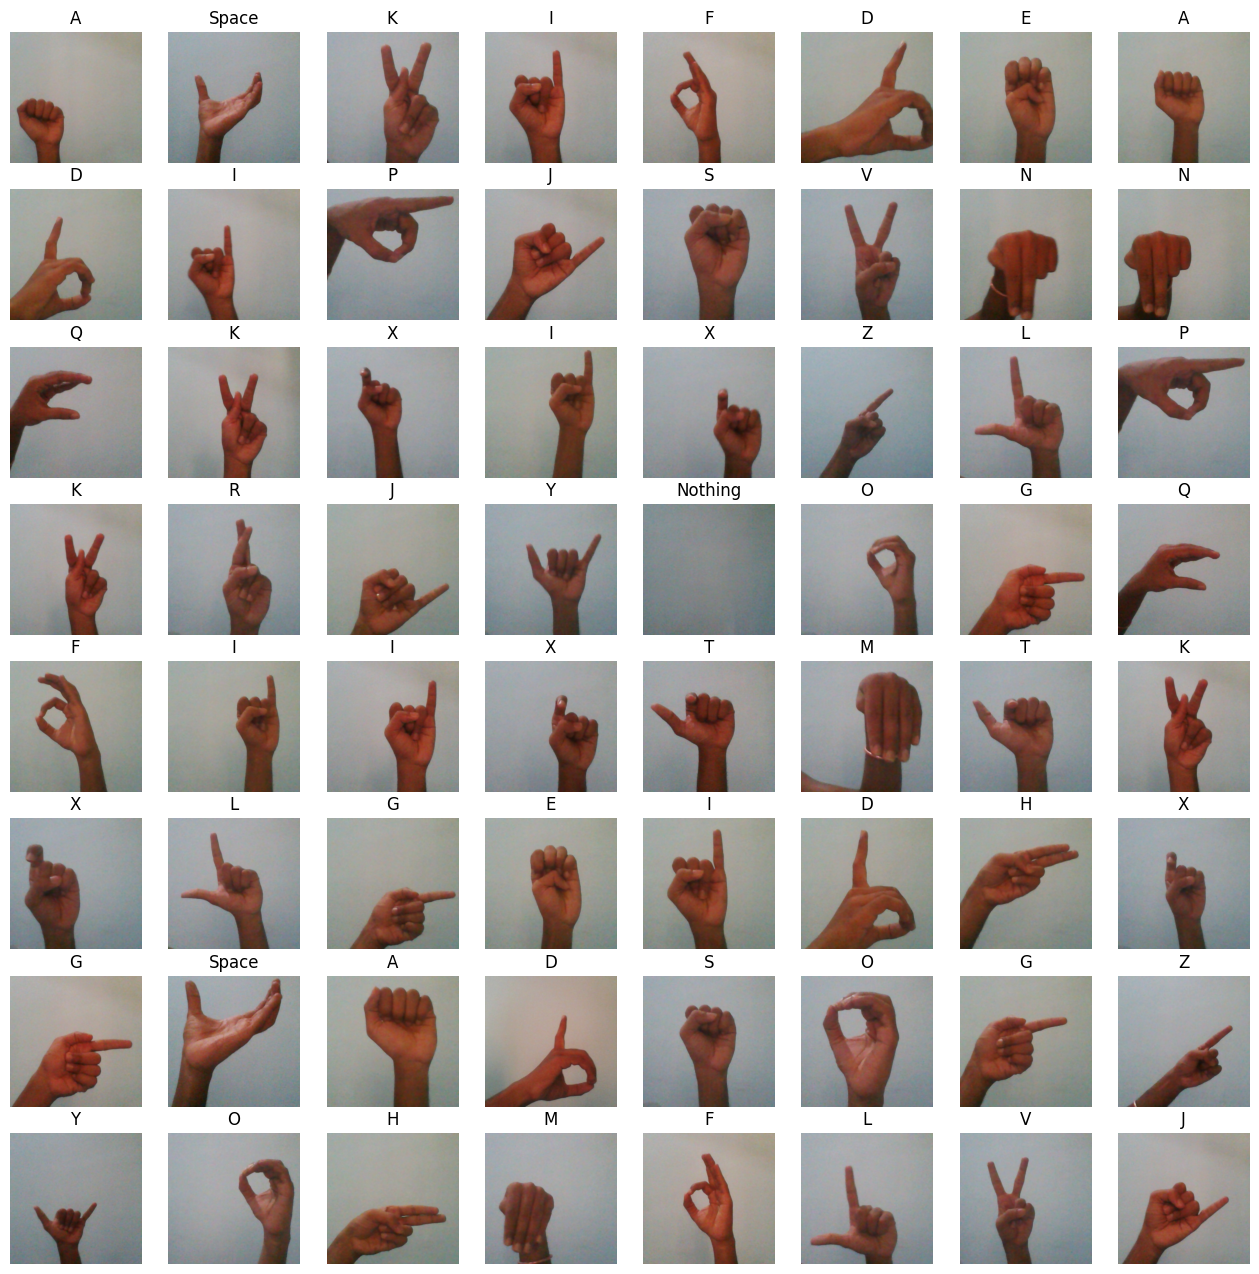

In [6]:
def show_random_images(df, num_images=64):
    plt.figure(figsize=(16,16))
    for i in range(num_images):
        row = df.sample(1).iloc[0]
        img = Image.open(row['filepath'])

        plt.subplot(8,8,i+1)
        plt.imshow(img)
        plt.title(row['label'])
        plt.axis("off")

show_random_images(train_df)

In [7]:
sample_img = Image.open(train_df.sample(1).iloc[0]["filepath"])
img_array = np.array(sample_img)

print("Sample image shape:", img_array.shape)

Sample image shape: (400, 400, 3)


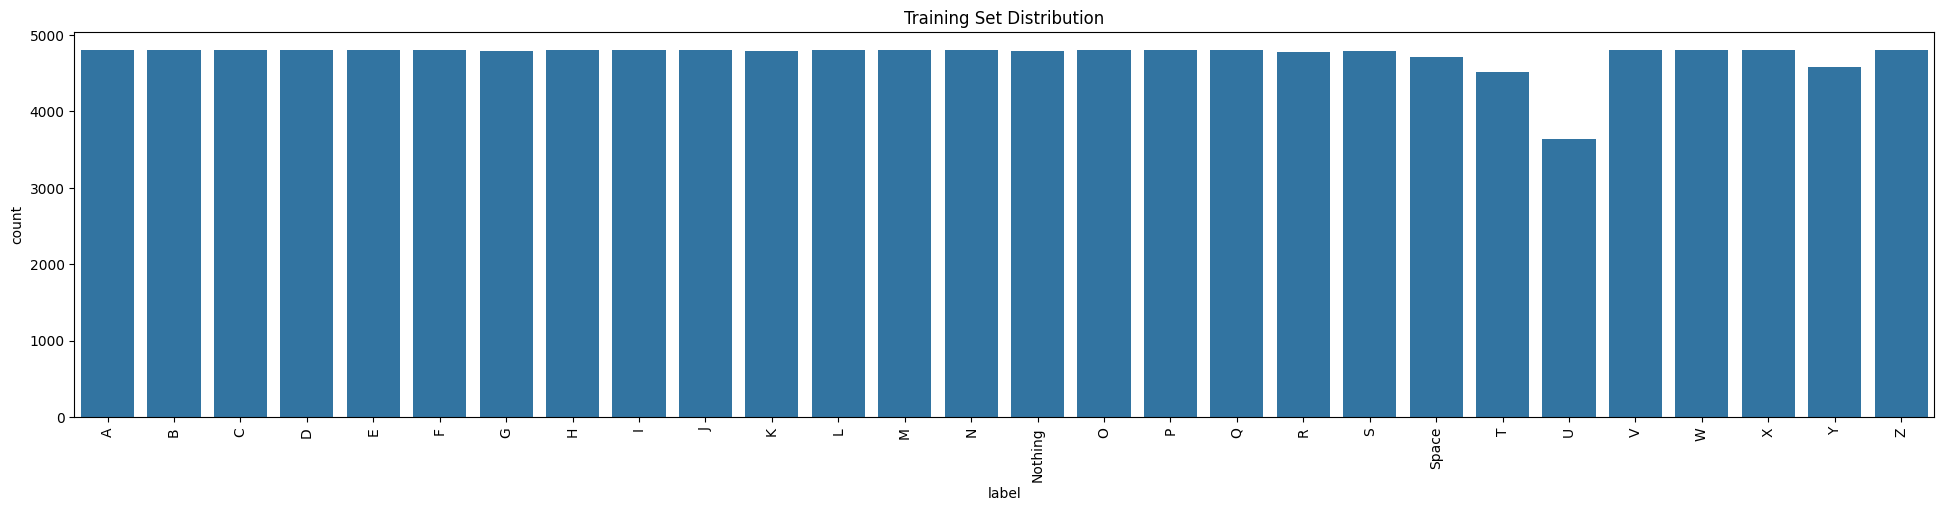

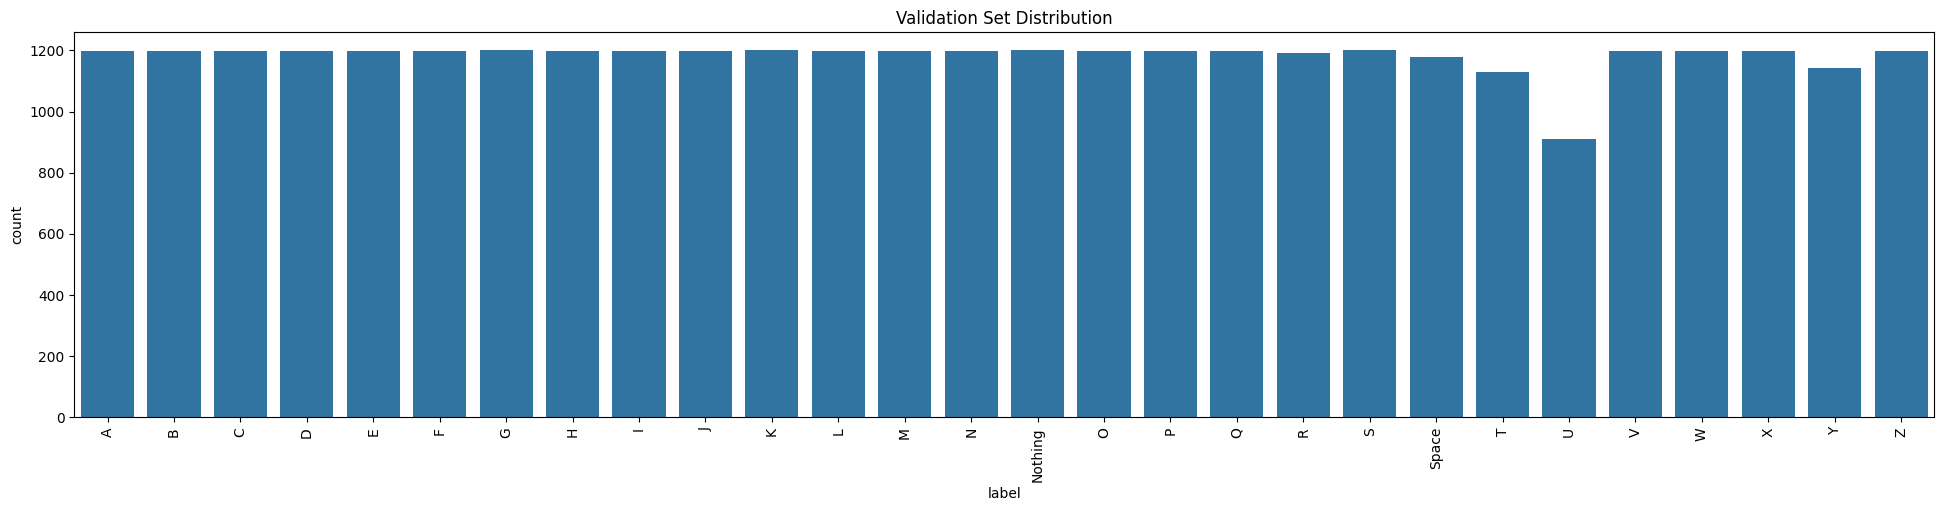

In [8]:
def plot_distribution(df, title):
    plt.figure(figsize=(24,5))
    sns.countplot(x=df['label'], order=class_names)
    plt.title(title)
    plt.xticks(rotation=90)
    plt.show()

plot_distribution(train_df, "Training Set Distribution")
plot_distribution(val_df, "Validation Set Distribution")

## DATA preprocessing

In [9]:
IMG_SIZE = 64   

USE_GRAYSCALE = True

if USE_GRAYSCALE:
    MEAN = [0.5]
    STD = [0.5]
else: # from image net dataset
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

Torch data transformation pipeline

In [10]:
from torchvision.transforms import v2 # for CPU

base_preprocess = [
    T.Resize((IMG_SIZE, IMG_SIZE))
]

if USE_GRAYSCALE:
    base_preprocess.append(T.Grayscale(num_output_channels=1))

train_transform = v2.Compose([
    v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ConvertImageDtype(torch.float32),
    v2.Normalize(mean=[0.5], std=[0.5]),
])

eval_transforms = T.Compose([
    *base_preprocess,
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

In [11]:
from torch.utils.data import Dataset
# can't load using Image folder so custom implementation is required

class ASLFrameDataset(Dataset):
    def __init__(self, df, transform=None, class_to_idx=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")  # grayscale handled later... Don't forget to implement
        label = self.class_to_idx[row["label"]]
        
        if self.transform:
            img = self.transform(img)

        return img, label

In [14]:
from torchvision.datasets import ImageFolder
class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}

train_dataset =  ImageFolder(TRAIN_PATH, transform=train_transform)

val_dataset = ASLFrameDataset(
    df=val_df,
    transform=eval_transforms,
    class_to_idx=class_to_idx
)

In [15]:
from torchvision.datasets import ImageFolder

test_dataset = ImageFolder(
    root=TEST_PATH,
    transform=eval_transforms
)

In [16]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=False,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False # for gpu 
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

Visual debug check 

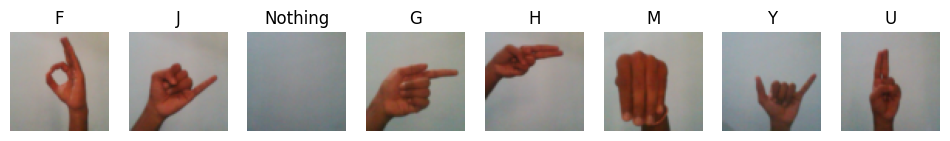

In [17]:

def show_batch(dataloader, n=8):
    images, labels = next(iter(dataloader))

    images = images[:n]
    labels = labels[:n]

    plt.figure(figsize=(12,3))
    for i in range(n):
        img = images[i].numpy().transpose(1,2,0)

        img = img * np.array(STD) + np.array(MEAN)
        img = np.clip(img, 0, 1)

        plt.subplot(1,n,i+1)
        if USE_GRAYSCALE:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img)
        plt.title(list(class_to_idx.keys())[labels[i]])
        plt.axis("off")

show_batch(train_loader)